# 39 — Continuous Gemma measurement portability

**Question.** Exact numeric endpoints failed to transfer across Gemma 31B and
26B, and Notebook 38 showed that independent binary headline thresholds
collide on 99.29% of directional firm-opens. Does a continuous,
cross-sectionally ranked firm-open signal retain enough agreement across the
two Gemma checkpoints to define a defensible future strategy base?

**Return firewall.** This notebook never loads open, close, or return columns.
It reads only score metadata plus symbol/session calendars. Every diagnostic
is measurement- or schedule-based. No current LSEG return is evaluated.

**Frozen portability gates (declared before execution).** A reducer must have
at least 95% paired coverage, firm-open Spearman at least 0.50, median daily
cross-sectional Spearman at least 0.40, sign agreement at least 70%, and mean
top-two plus bottom-two Jaccard at least 0.25 per leg. Its adaptive event
schedule must have at least 15 active dates per model, active-date Jaccard at
least 0.50, and mean top/bottom Jaccard at least 0.25 on shared active dates.
The first passing reducer in the predeclared simplicity order is retained;
otherwise the portable-signal route is rejected.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import build_aggregation_panel  # noqa: E402
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    load_success_scores,
    map_headlines_to_entry_sessions,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402

SEED = 20260813
TOP_BOTTOM_NAMES = 2
TRAILING_SESSIONS = 60
MIN_TRAILING_SESSIONS = 40
EVENT_INTENSITY_QUANTILE = 0.75
MIN_PAIRED_COVERAGE = 0.95
MIN_FIRM_SPEARMAN = 0.50
MIN_MEDIAN_DAILY_SPEARMAN = 0.40
MIN_SIGN_AGREEMENT = 0.70
MIN_LEG_JACCARD = 0.25
MIN_ACTIVE_DATES = 15
MIN_ACTIVE_DATE_JACCARD = 0.50
REDUCER_ORDER = (
    "mean_continuous",
    "trimmed_mean",
    "median_continuous",
    "strongest_event",
    "mean_hard_label",
)

COLLECTION_DIR = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA31_PATH = (
    REPO_ROOT
    / "Data/collections/lseg_us_sector_33_6m/derived/headline_scores_gemma-4-31b_soft.csv"
)
GEMMA26_PATH = (
    COLLECTION_DIR
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
SECTOR33_CALENDAR_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
ADD11_CALENDAR_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/39_gemma_continuous_portability"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Frozen shared-score population

The later complete checkpoint supplies canonical associations and timestamps.
Headline text is excluded. The older checkpoint remains a partial,
hash-ordered failed-run recovery without a completed adjacent manifest, so
all conclusions are measurement stress tests rather than a scorer bake-off.

In [2]:
gemma26_scores, gemma26_input_audit = load_success_scores(
    GEMMA26_PATH, scorer="gemma4_26b"
)
gemma31_history = pd.read_csv(
    GEMMA31_PATH,
    usecols=["headline_sha256", "model_id", "label", "score", "status", "error"],
    low_memory=False,
)
gemma31_success = gemma31_history.loc[gemma31_history["status"].eq("success")].copy()
gemma31_success["score"] = pd.to_numeric(gemma31_success["score"], errors="raise")
if gemma31_success["headline_sha256"].duplicated().any():
    raise ValueError("older Gemma checkpoint has duplicate successes")
if not gemma31_success["score"].between(-1.0, 1.0).all():
    raise ValueError("older Gemma checkpoint has scores outside [-1, 1]")
model_ids = sorted(gemma31_success["model_id"].dropna().astype(str).unique())
if model_ids != ["gemma-4-31b"]:
    raise ValueError(f"unexpected older Gemma model identities: {model_ids}")

shared_hashes = set(gemma31_success["headline_sha256"]) & set(
    gemma26_scores["headline_sha256"]
)
if len(shared_hashes) != 85_960:
    raise ValueError(f"expected 85,960 shared successful hashes, found {len(shared_hashes):,}")

metadata_columns = [
    "headline_sha256",
    "matched_symbols",
    "first_timestamp",
    "explicit_target",
    "contextual",
    "market_price_technical",
]
canonical_metadata = gemma26_scores.loc[
    gemma26_scores["headline_sha256"].isin(shared_hashes), metadata_columns
].copy()


def matched_score_frame(scores: pd.DataFrame, *, scorer: str) -> pd.DataFrame:
    out = canonical_metadata.merge(
        scores[["headline_sha256", "label", "score"]],
        on="headline_sha256",
        validate="one_to_one",
    )
    if len(out) != len(shared_hashes):
        raise ValueError(f"{scorer} does not cover the shared population")
    out["scorer"] = scorer
    return out


matched_scores = {
    "gemma31_cerebras": matched_score_frame(
        gemma31_success, scorer="gemma31_cerebras"
    ),
    "gemma26_deepinfra": matched_score_frame(
        gemma26_scores, scorer="gemma26_deepinfra"
    ),
}
headline_pair = (
    matched_scores["gemma31_cerebras"][["headline_sha256", "score"]]
    .rename(columns={"score": "score_31"})
    .merge(
        matched_scores["gemma26_deepinfra"][["headline_sha256", "score"]].rename(
            columns={"score": "score_26"}
        ),
        on="headline_sha256",
        validate="one_to_one",
    )
)
headline_metrics = pd.DataFrame(
    [
        {
            "shared_headlines": len(headline_pair),
            "pearson": float(headline_pair["score_31"].corr(headline_pair["score_26"])),
            "spearman": float(
                headline_pair["score_31"].corr(
                    headline_pair["score_26"], method="spearman"
                )
            ),
            "sign_agreement": float(
                np.sign(headline_pair["score_31"])
                .eq(np.sign(headline_pair["score_26"]))
                .mean()
            ),
            "gemma31_unique_scores": int(headline_pair["score_31"].nunique()),
            "gemma26_unique_scores": int(headline_pair["score_26"].nunique()),
        }
    ]
)
display(headline_metrics.T)

,0
shared_headlines,"85,960.000000"
pearson,0.959857
spearman,0.953231
sign_agreement,0.891694
gemma31_unique_scores,48.000000
gemma26_unique_scores,58.000000


## Return-free firm-open aggregation

Only symbol and session-date columns are read from the two calendar files.
The existing 30-minute information buffer and aggregation helpers are reused,
but no price value or outcome enters this notebook.

In [3]:
calendar_pieces = []
for calendar_path in (SECTOR33_CALENDAR_PATH, ADD11_CALENDAR_PATH):
    piece = pd.read_csv(calendar_path, usecols=["symbol", "session_date"])
    calendar_pieces.append(piece)
calendar = pd.concat(calendar_pieces, ignore_index=True)
calendar["symbol"] = calendar["symbol"].astype(str)
calendar["session_date"] = pd.to_datetime(calendar["session_date"]).dt.normalize()
if calendar.duplicated(["symbol", "session_date"]).any():
    raise ValueError("session calendar has duplicate symbol-date rows")

original_symbols = tuple(
    symbol for members in SECTOR_MEMBERS.values() for symbol in members[:3]
)
original_set = set(original_symbols)
matched_panels = {}
association_counts = {}
for scorer, frame in matched_scores.items():
    events = map_headlines_to_entry_sessions(frame, calendar)
    events = events.loc[events["symbol"].isin(original_set)].copy()
    association_counts[scorer] = len(events)
    firm_open_keys = (
        events[["symbol", "entry_session"]]
        .drop_duplicates()
        .rename(columns={"entry_session": "session_date"})
    )
    firm_open_keys["split"] = "return_free_measurement"
    matched_panels[scorer] = build_aggregation_panel(
        firm_open_keys, stories=events
    ).sort_values(["session_date", "symbol"], kind="mergesort")

complete_sets = {
    scorer: set(
        panel.groupby("session_date")["symbol"]
        .nunique()
        .loc[lambda counts: counts.eq(33)]
        .index
    )
    for scorer, panel in matched_panels.items()
}
common_complete_sessions = set.intersection(*complete_sets.values())
if len(common_complete_sessions) != 118:
    raise ValueError(
        f"expected 118 common complete sessions, found {len(common_complete_sessions)}"
    )
for scorer, panel in matched_panels.items():
    use = panel.loc[panel["session_date"].isin(common_complete_sessions)].copy()
    if len(use) != 118 * 33:
        raise RuntimeError(f"{scorer} common panel is not rectangular")
    matched_panels[scorer] = use.sort_values(
        ["session_date", "symbol"], kind="mergesort"
    ).reset_index(drop=True)


def jaccard(left: set[str] | set[pd.Timestamp], right: set[str] | set[pd.Timestamp]) -> float:
    union = left | right
    return len(left & right) / len(union) if union else float("nan")


def leg_sets(day: pd.DataFrame, value_col: str) -> tuple[set[str], set[str]]:
    valid = day.dropna(subset=[value_col]).copy()
    if len(valid) < 2 * TOP_BOTTOM_NAMES:
        return set(), set()
    ordered = valid.sort_values(
        [value_col, "symbol"], ascending=[True, True], kind="mergesort"
    )
    bottom = set(ordered.head(TOP_BOTTOM_NAMES)["symbol"])
    top = set(ordered.tail(TOP_BOTTOM_NAMES)["symbol"])
    if top & bottom:
        raise RuntimeError("top and bottom legs overlap")
    return top, bottom


def paired_reducer_frame(reducer: str) -> pd.DataFrame:
    left = matched_panels["gemma31_cerebras"][
        ["session_date", "symbol", reducer]
    ].rename(columns={reducer: "value_31"})
    right = matched_panels["gemma26_deepinfra"][
        ["session_date", "symbol", reducer]
    ].rename(columns={reducer: "value_26"})
    pair = left.merge(
        right,
        on=["session_date", "symbol"],
        validate="one_to_one",
    )
    if len(pair) != 118 * 33:
        raise RuntimeError("paired reducer frame is not rectangular")
    return pair


portability_rows = []
daily_rank_rows = []
leg_overlap_rows = []
paired_reducers = {}
for reducer in REDUCER_ORDER:
    pair = paired_reducer_frame(reducer)
    paired_reducers[reducer] = pair
    defined = pair[["value_31", "value_26"]].notna().all(axis=1)
    use = pair.loc[defined].copy()
    daily_spearman = use.groupby("session_date").apply(
        lambda day: day["value_31"].corr(day["value_26"], method="spearman"),
        include_groups=False,
    )
    for session, value in daily_spearman.items():
        daily_rank_rows.append(
            {"reducer": reducer, "session_date": session, "spearman": value}
        )
    top_jaccards = []
    bottom_jaccards = []
    for session, day in pair.groupby("session_date", sort=True):
        top31, bottom31 = leg_sets(
            day.rename(columns={"value_31": "value"}), "value"
        )
        top26, bottom26 = leg_sets(
            day.rename(columns={"value_26": "value"}), "value"
        )
        top_overlap = jaccard(top31, top26)
        bottom_overlap = jaccard(bottom31, bottom26)
        top_jaccards.append(top_overlap)
        bottom_jaccards.append(bottom_overlap)
        leg_overlap_rows.append(
            {
                "reducer": reducer,
                "session_date": session,
                "top_jaccard": top_overlap,
                "bottom_jaccard": bottom_overlap,
            }
        )
    portability_rows.append(
        {
            "reducer": reducer,
            "paired_coverage": float(defined.mean()),
            "firm_open_pearson": float(use["value_31"].corr(use["value_26"])),
            "firm_open_spearman": float(
                use["value_31"].corr(use["value_26"], method="spearman")
            ),
            "sign_agreement": float(
                np.sign(use["value_31"]).eq(np.sign(use["value_26"])).mean()
            ),
            "median_daily_spearman": float(daily_spearman.median()),
            "daily_spearman_q25": float(daily_spearman.quantile(0.25)),
            "mean_top2_jaccard": float(np.nanmean(top_jaccards)),
            "mean_bottom2_jaccard": float(np.nanmean(bottom_jaccards)),
        }
    )
portability = pd.DataFrame(portability_rows)
portability["firm_portability_gate"] = (
    portability["paired_coverage"].ge(MIN_PAIRED_COVERAGE)
    & portability["firm_open_spearman"].ge(MIN_FIRM_SPEARMAN)
    & portability["median_daily_spearman"].ge(MIN_MEDIAN_DAILY_SPEARMAN)
    & portability["sign_agreement"].ge(MIN_SIGN_AGREEMENT)
    & portability["mean_top2_jaccard"].ge(MIN_LEG_JACCARD)
    & portability["mean_bottom2_jaccard"].ge(MIN_LEG_JACCARD)
)
daily_ranks = pd.DataFrame(daily_rank_rows)
leg_overlaps = pd.DataFrame(leg_overlap_rows)
display(portability)

/Users/peterprendergast/Documents/Sentiment_Dissertation/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,reducer,paired_coverage,firm_open_pearson,firm_open_spearman,sign_agreement,median_daily_spearman,daily_spearman_q25,mean_top2_jaccard,mean_bottom2_jaccard,firm_portability_gate
0,mean_continuous,1.000000,0.985091,0.982567,0.938624,0.977063,0.967850,0.720339,0.864407,True
1,trimmed_mean,1.000000,0.984558,0.982149,0.941192,0.976394,0.967119,0.680791,0.870056,True
2,median_continuous,1.000000,0.955111,0.941979,0.851567,0.941434,0.916208,0.562147,0.762712,True
3,strongest_event,0.724448,0.521573,0.444448,0.695853,0.427531,0.270172,0.101695,0.132768,False
4,mean_hard_label,1.000000,0.958875,0.951959,0.888546,0.950006,0.931570,0.697740,0.762712,True


## Scale-free adaptive event schedule

For each model and reducer, event intensity is the cross-sectional 90th-minus-
10th percentile spread. A date becomes active only when its spread is at or
above the 75th percentile of the strictly prior 60 sessions, with at least 40
prior observations. This makes timing adaptive to each model's score scale.
On an active date, the future portfolio template is the top two and bottom two
firms, which is the minimum breadth that can consume both 50% legs under the
existing 25% single-name cap.

In [4]:
schedule_rows = []
schedule_daily_rows = []
for reducer in REDUCER_ORDER:
    per_model = {}
    for model_suffix, value_col in (("31", "value_31"), ("26", "value_26")):
        pair = paired_reducers[reducer]
        spread = pair.groupby("session_date")[value_col].apply(
            lambda values: float(values.quantile(0.90) - values.quantile(0.10))
        )
        spread = spread.sort_index()
        trailing_threshold = spread.shift(1).rolling(
            TRAILING_SESSIONS, min_periods=MIN_TRAILING_SESSIONS
        ).quantile(EVENT_INTENSITY_QUANTILE)
        active = spread.ge(trailing_threshold) & trailing_threshold.notna()
        per_model[model_suffix] = pd.DataFrame(
            {
                "session_date": spread.index,
                f"spread_{model_suffix}": spread.to_numpy(),
                f"threshold_{model_suffix}": trailing_threshold.to_numpy(),
                f"active_{model_suffix}": active.to_numpy(),
            }
        )
    schedule = per_model["31"].merge(
        per_model["26"], on="session_date", validate="one_to_one"
    )
    active31 = set(schedule.loc[schedule["active_31"], "session_date"])
    active26 = set(schedule.loc[schedule["active_26"], "session_date"])
    shared_active = active31 & active26
    shared_top = []
    shared_bottom = []
    pair = paired_reducers[reducer]
    for session in sorted(shared_active):
        day = pair.loc[pair["session_date"].eq(session)]
        top31, bottom31 = leg_sets(
            day.rename(columns={"value_31": "value"}), "value"
        )
        top26, bottom26 = leg_sets(
            day.rename(columns={"value_26": "value"}), "value"
        )
        shared_top.append(jaccard(top31, top26))
        shared_bottom.append(jaccard(bottom31, bottom26))
    row = {
        "reducer": reducer,
        "gemma31_active_dates": len(active31),
        "gemma26_active_dates": len(active26),
        "shared_active_dates": len(shared_active),
        "active_date_jaccard": jaccard(active31, active26),
        "shared_active_top2_jaccard": float(np.nanmean(shared_top))
        if shared_top
        else float("nan"),
        "shared_active_bottom2_jaccard": float(np.nanmean(shared_bottom))
        if shared_bottom
        else float("nan"),
    }
    schedule_rows.append(row)
    schedule["reducer"] = reducer
    schedule_daily_rows.append(schedule)
schedule_portability = pd.DataFrame(schedule_rows)
schedule_portability["schedule_portability_gate"] = (
    schedule_portability[["gemma31_active_dates", "gemma26_active_dates"]]
    .min(axis=1)
    .ge(MIN_ACTIVE_DATES)
    & schedule_portability["active_date_jaccard"].ge(MIN_ACTIVE_DATE_JACCARD)
    & schedule_portability["shared_active_top2_jaccard"].ge(MIN_LEG_JACCARD)
    & schedule_portability["shared_active_bottom2_jaccard"].ge(MIN_LEG_JACCARD)
)
schedule_daily = pd.concat(schedule_daily_rows, ignore_index=True)
candidate_gates = portability.merge(
    schedule_portability, on="reducer", validate="one_to_one"
)
candidate_gates["candidate_gate"] = (
    candidate_gates["firm_portability_gate"]
    & candidate_gates["schedule_portability_gate"]
)
candidate_gates["simplicity_order"] = candidate_gates["reducer"].map(
    {name: index for index, name in enumerate(REDUCER_ORDER)}
)
passing = candidate_gates.loc[candidate_gates["candidate_gate"]].sort_values(
    "simplicity_order", kind="mergesort"
)
selected_reducer = None if passing.empty else str(passing.iloc[0]["reducer"])
display(schedule_portability)
display(candidate_gates)
print("Selected reducer:", selected_reducer)

,reducer,gemma31_active_dates,gemma26_active_dates,shared_active_dates,active_date_jaccard,shared_active_top2_jaccard,shared_active_bottom2_jaccard,schedule_portability_gate
0,mean_continuous,22,22,17,0.629630,0.647059,0.921569,True
1,trimmed_mean,23,18,16,0.640000,0.750000,0.958333,True
2,median_continuous,24,25,22,0.814815,0.545455,0.681818,True
3,strongest_event,19,67,17,0.246377,0.156863,0.117647,False
4,mean_hard_label,23,21,15,0.517241,0.822222,0.777778,True


,reducer,paired_coverage,firm_open_pearson,firm_open_spearman,sign_agreement,median_daily_spearman,daily_spearman_q25,mean_top2_jaccard,mean_bottom2_jaccard,firm_portability_gate,gemma31_active_dates,gemma26_active_dates,shared_active_dates,active_date_jaccard,shared_active_top2_jaccard,shared_active_bottom2_jaccard,schedule_portability_gate,candidate_gate,simplicity_order
0,mean_continuous,1.000000,0.985091,0.982567,0.938624,0.977063,0.967850,0.720339,0.864407,True,22,22,17,0.629630,0.647059,0.921569,True,True,0
1,trimmed_mean,1.000000,0.984558,0.982149,0.941192,0.976394,0.967119,0.680791,0.870056,True,23,18,16,0.640000,0.750000,0.958333,True,True,1
2,median_continuous,1.000000,0.955111,0.941979,0.851567,0.941434,0.916208,0.562147,0.762712,True,24,25,22,0.814815,0.545455,0.681818,True,True,2
3,strongest_event,0.724448,0.521573,0.444448,0.695853,0.427531,0.270172,0.101695,0.132768,False,19,67,17,0.246377,0.156863,0.117647,False,False,3
4,mean_hard_label,1.000000,0.958875,0.951959,0.888546,0.950006,0.931570,0.697740,0.762712,True,23,21,15,0.517241,0.822222,0.777778,True,True,4


Selected reducer: mean_continuous


## Complete 888,155-headline input-only deployment audit

The selected reducer is now applied once to the complete 26B checkpoint. This
checks only whether the frozen rule yields a feasible schedule on all 167
original-33 sessions. It still does not load or join any return.

In [5]:
if selected_reducer is None:
    raise RuntimeError("no portable reducer is available for the complete-input audit")
full_events = map_headlines_to_entry_sessions(gemma26_scores, calendar)
full_events = full_events.loc[full_events["symbol"].isin(original_set)].copy()
full_keys = (
    full_events[["symbol", "entry_session"]]
    .drop_duplicates()
    .rename(columns={"entry_session": "session_date"})
)
full_keys["split"] = "return_free_measurement"
full_panel = build_aggregation_panel(full_keys, stories=full_events)
full_panel = full_panel.sort_values(
    ["session_date", "symbol"], kind="mergesort"
).reset_index(drop=True)
full_complete = (
    full_panel.groupby("session_date")["symbol"]
    .nunique()
    .loc[lambda counts: counts.eq(33)]
    .index
)
if len(full_complete) != 167 or len(full_panel) != 167 * 33:
    raise RuntimeError("complete 26B firm-open panel is not the expected 167 x 33")

full_spread = full_panel.groupby("session_date")[selected_reducer].apply(
    lambda values: float(values.quantile(0.90) - values.quantile(0.10))
)
full_spread = full_spread.sort_index()
full_threshold = full_spread.shift(1).rolling(
    TRAILING_SESSIONS, min_periods=MIN_TRAILING_SESSIONS
).quantile(EVENT_INTENSITY_QUANTILE)
full_active = full_spread.ge(full_threshold) & full_threshold.notna()
full_schedule_rows = []
for session in full_spread.index:
    day = full_panel.loc[full_panel["session_date"].eq(session)].rename(
        columns={selected_reducer: "value"}
    )
    top, bottom = leg_sets(day, "value")
    full_schedule_rows.append(
        {
            "session_date": session,
            "spread": float(full_spread.loc[session]),
            "trailing_threshold": float(full_threshold.loc[session])
            if pd.notna(full_threshold.loc[session])
            else float("nan"),
            "active": bool(full_active.loc[session]),
            "long_symbols": "|".join(sorted(top)) if full_active.loc[session] else "",
            "short_symbols": "|".join(sorted(bottom)) if full_active.loc[session] else "",
        }
    )
full_input_schedule = pd.DataFrame(full_schedule_rows)
active_input_schedule = full_input_schedule.loc[full_input_schedule["active"]]
full_input_summary = pd.DataFrame(
    [
        {
            "complete_headlines": len(gemma26_scores),
            "original33_associations": len(full_events),
            "firm_open_rows": len(full_panel),
            "sessions": len(full_complete),
            "sessions_after_warmup": int(full_threshold.notna().sum()),
            "active_sessions": int(full_active.sum()),
            "active_share_after_warmup": float(
                full_active.sum() / full_threshold.notna().sum()
            ),
            "first_active_session": active_input_schedule["session_date"].min(),
            "last_active_session": active_input_schedule["session_date"].max(),
            "return_columns_loaded": False,
        }
    ]
)
display(full_input_summary.T)

,0
complete_headlines,888155
original33_associations,800145
firm_open_rows,5511
sessions,167
sessions_after_warmup,127
active_sessions,40
active_share_after_warmup,0.314961
first_active_session,2025-12-29 00:00:00
last_active_session,2026-06-26 00:00:00
return_columns_loaded,False


## Figures

findfont: Failed to find font weight medium, now using 400.


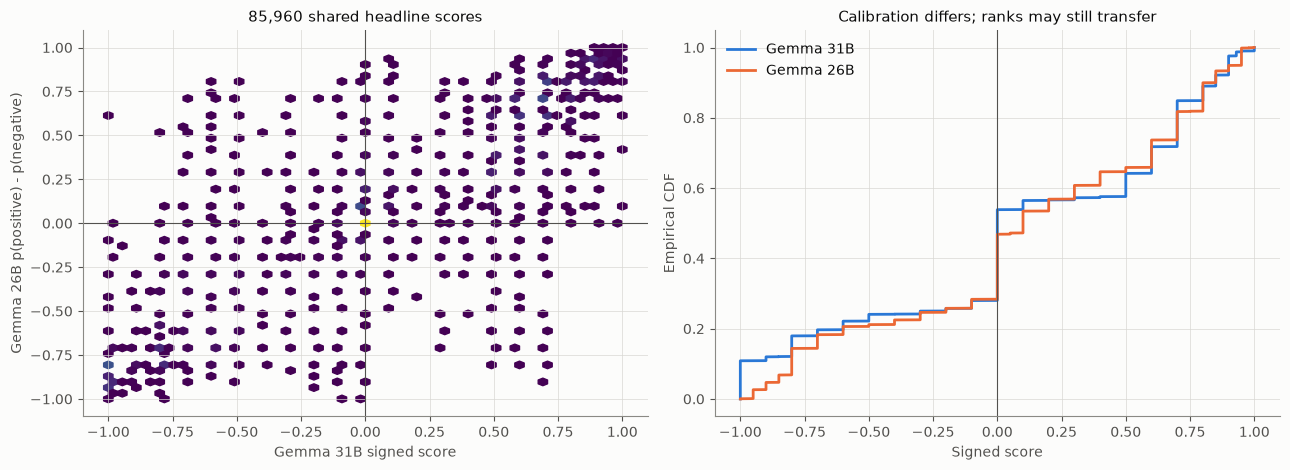

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hexbin(
    headline_pair["score_31"],
    headline_pair["score_26"],
    gridsize=55,
    mincnt=1,
    cmap="viridis",
)
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_xlabel("Gemma 31B signed score")
axes[0].set_ylabel("Gemma 26B p(positive) - p(negative)")
axes[0].set_title("85,960 shared headline scores")
for label, column, colour in (
    ("Gemma 31B", "score_31", CATEGORICAL[0]),
    ("Gemma 26B", "score_26", CATEGORICAL[1]),
):
    values = np.sort(headline_pair[column].to_numpy(dtype=float))
    axes[1].plot(values, np.linspace(0.0, 1.0, len(values)), label=label, color=colour)
axes[1].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Signed score")
axes[1].set_ylabel("Empirical CDF")
axes[1].set_title("Calibration differs; ranks may still transfer")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "headline_score_portability.png", dpi=170, bbox_inches="tight")
plt.show()

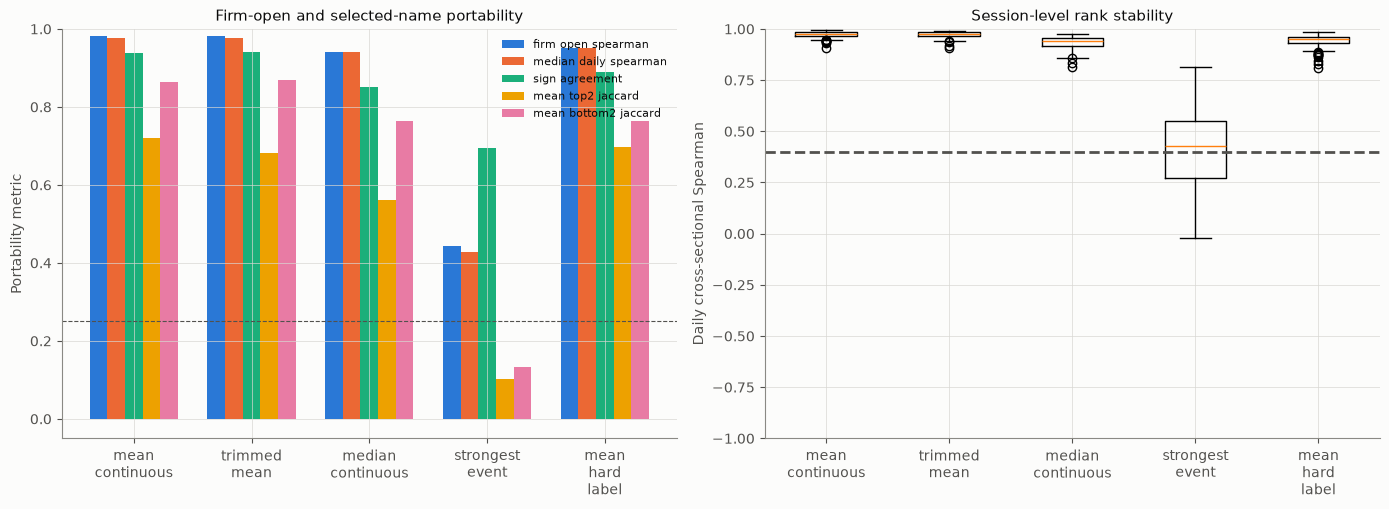

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
metric_columns = [
    "firm_open_spearman",
    "median_daily_spearman",
    "sign_agreement",
    "mean_top2_jaccard",
    "mean_bottom2_jaccard",
]
x = np.arange(len(REDUCER_ORDER))
width = 0.15
for index, metric in enumerate(metric_columns):
    values = portability.set_index("reducer").loc[list(REDUCER_ORDER), metric]
    axes[0].bar(
        x + (index - 2) * width,
        values,
        width=width,
        label=metric.replace("_", " "),
        color=CATEGORICAL[index],
    )
axes[0].axhline(0.25, color=INK["reference"], linewidth=0.8, linestyle="--")
axes[0].set_xticks(x, [name.replace("_", "\n") for name in REDUCER_ORDER])
axes[0].set_ylim(-0.05, 1.0)
axes[0].set_ylabel("Portability metric")
axes[0].set_title("Firm-open and selected-name portability")
axes[0].legend(loc="best", fontsize=8)
daily_groups = [
    daily_ranks.loc[daily_ranks["reducer"].eq(reducer), "spearman"].dropna()
    for reducer in REDUCER_ORDER
]
axes[1].boxplot(daily_groups, tick_labels=[name.replace("_", "\n") for name in REDUCER_ORDER])
axes[1].axhline(MIN_MEDIAN_DAILY_SPEARMAN, color=INK["reference"], linestyle="--")
axes[1].set_ylim(-1.0, 1.0)
axes[1].set_ylabel("Daily cross-sectional Spearman")
axes[1].set_title("Session-level rank stability")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "firm_open_reducer_portability.png", dpi=170, bbox_inches="tight")
plt.show()

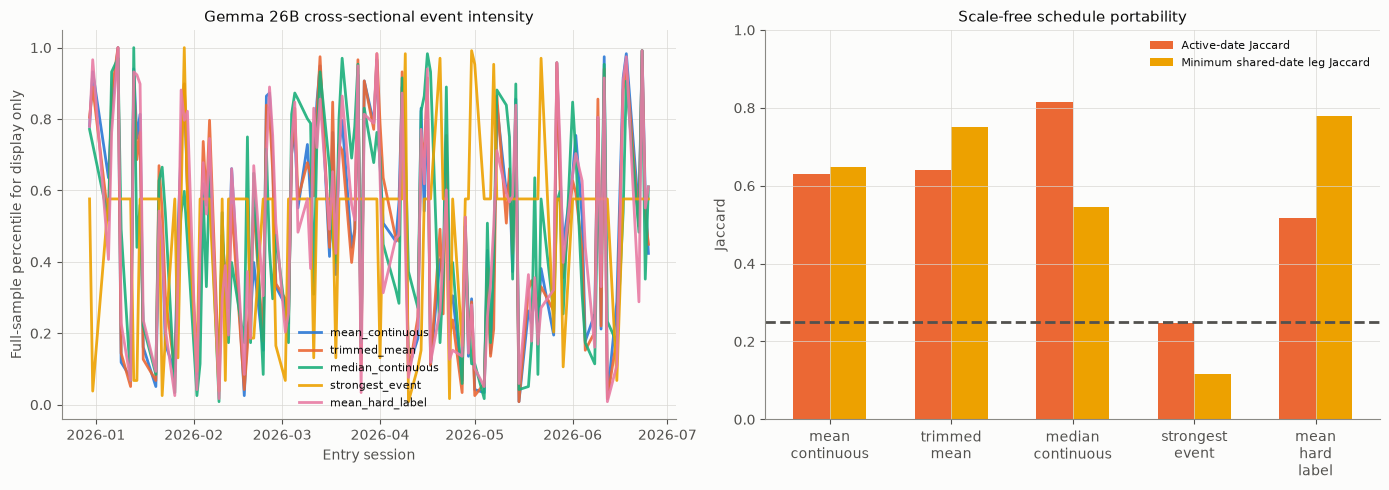

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
for reducer, colour in zip(
    REDUCER_ORDER, CATEGORICAL[: len(REDUCER_ORDER)], strict=True
):
    use = schedule_daily.loc[schedule_daily["reducer"].eq(reducer)]
    axes[0].plot(
        use["session_date"],
        use["spread_26"].rank(pct=True),
        label=reducer,
        color=colour,
        alpha=0.9,
    )
axes[0].set_xlabel("Entry session")
axes[0].set_ylabel("Full-sample percentile for display only")
axes[0].set_title("Gemma 26B cross-sectional event intensity")
axes[0].legend(loc="best", fontsize=8)
schedule_plot = schedule_portability.set_index("reducer").loc[list(REDUCER_ORDER)]
axes[1].bar(
    x - 0.15,
    schedule_plot["active_date_jaccard"],
    width=0.3,
    color=CATEGORICAL[1],
    label="Active-date Jaccard",
)
axes[1].bar(
    x + 0.15,
    schedule_plot[["shared_active_top2_jaccard", "shared_active_bottom2_jaccard"]].min(axis=1),
    width=0.3,
    color=CATEGORICAL[3],
    label="Minimum shared-date leg Jaccard",
)
axes[1].axhline(MIN_LEG_JACCARD, color=INK["reference"], linestyle="--")
axes[1].set_xticks(x, [name.replace("_", "\n") for name in REDUCER_ORDER])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel("Jaccard")
axes[1].set_title("Scale-free schedule portability")
axes[1].legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "adaptive_schedule_portability.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence

In [9]:
headline_metrics.to_csv(OUTPUT_DIR / "headline_metrics.csv", index=False)
portability.to_csv(OUTPUT_DIR / "firm_open_portability.csv", index=False)
daily_ranks.to_csv(OUTPUT_DIR / "daily_rank_correlations.csv", index=False)
leg_overlaps.to_csv(OUTPUT_DIR / "daily_leg_overlaps.csv", index=False)
schedule_portability.to_csv(OUTPUT_DIR / "schedule_portability.csv", index=False)
schedule_daily.to_csv(OUTPUT_DIR / "schedule_daily_input_only.csv", index=False)
candidate_gates.to_csv(OUTPUT_DIR / "candidate_gates.csv", index=False)
full_input_schedule.to_csv(OUTPUT_DIR / "full_26b_input_schedule.csv", index=False)
full_input_summary.to_csv(OUTPUT_DIR / "full_26b_input_summary.csv", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

selected_specification = (
    None
    if selected_reducer is None
    else {
        "firm_open_reducer": selected_reducer,
        "scale_normalization": "cross-sectional ranks and trailing spread quantile",
        "event_intensity": "firm-open q90 minus q10",
        "event_gate": (
            "current spread >= strictly-prior trailing-60 75th percentile, "
            "minimum 40 prior sessions"
        ),
        "long_names": 2,
        "short_names": 2,
        "single_name_cap": 0.25,
        "gross_exposure": 1.0,
        "holding_intervals": 1,
        "cost_bps_per_side_for_future_test": 10.0,
        "current_return_window_evaluated": False,
    }
)
manifest = {
    "status": "RETURN_FREE_CONTINUOUS_GEMMA_PORTABILITY_AUDIT",
    "notebook": "39_gemma_continuous_portability.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma31_partial_checkpoint": str(GEMMA31_PATH.relative_to(REPO_ROOT)),
        "gemma31_checkpoint_sha256": sha256_file(GEMMA31_PATH),
        "gemma26_complete_checkpoint": str(GEMMA26_PATH.relative_to(REPO_ROOT)),
        "gemma26_checkpoint_sha256": gemma26_input_audit["output_sha256"],
        "sector33_calendar": str(SECTOR33_CALENDAR_PATH.relative_to(REPO_ROOT)),
        "add11_calendar": str(ADD11_CALENDAR_PATH.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
        "price_or_return_columns_loaded": False,
        "shared_hashes": len(shared_hashes),
        "common_complete_sessions": len(common_complete_sessions),
        "original_companies": len(original_symbols),
        "association_counts": association_counts,
    },
    "frozen_gates": {
        "minimum_paired_coverage": MIN_PAIRED_COVERAGE,
        "minimum_firm_open_spearman": MIN_FIRM_SPEARMAN,
        "minimum_median_daily_spearman": MIN_MEDIAN_DAILY_SPEARMAN,
        "minimum_sign_agreement": MIN_SIGN_AGREEMENT,
        "minimum_leg_jaccard": MIN_LEG_JACCARD,
        "minimum_active_dates_per_model": MIN_ACTIVE_DATES,
        "minimum_active_date_jaccard": MIN_ACTIVE_DATE_JACCARD,
        "reducer_order": list(REDUCER_ORDER),
    },
    "adaptive_schedule": {
        "top_bottom_names": TOP_BOTTOM_NAMES,
        "trailing_sessions": TRAILING_SESSIONS,
        "minimum_trailing_sessions": MIN_TRAILING_SESSIONS,
        "event_intensity_quantile": EVENT_INTENSITY_QUANTILE,
    },
    "headline_metrics": json.loads(headline_metrics.to_json(orient="records"))[0],
    "candidate_gates": json.loads(candidate_gates.to_json(orient="records")),
    "selected_reducer": selected_reducer,
    "selected_future_specification": selected_specification,
    "full_26b_input_summary": json.loads(
        full_input_summary.to_json(orient="records", date_format="iso")
    )[0],
    "limitations": [
        "the older 31B checkpoint is partial and hash ordered after a failed run",
        "31B has no completed adjacent manifest or probability columns",
        "canonical metadata comes from the complete 26B checkpoint",
        "the shared population covers 118 rectangular original-33 sessions",
        "portability thresholds are researcher judgments rather than return estimates",
        "adaptive spread thresholds have only a short 40-session warm-up",
        "no strategy return, alpha, or deployability claim is tested here",
        "a passing specification still requires genuinely new-date validation",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETURN_FREE_CONTINUOUS_GEMMA_PORTABILITY_AUDIT",
  "notebook": "39_gemma_continuous_portability.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260813,
  "input": {
    "gemma31_partial_checkpoint": "Data/collections/lseg_us_sector_33_6m/derived/headline_scores_gemma-4-31b_soft.csv",
    "gemma31_checkpoint_sha256": "3909dabfd0b4c6f93b5b786c4e361f159156cb42c819a4d30cbbb72cc5d28b41",
    "gemma26_complete_checkpoint": "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv",
    "gemma26_checkpoint_sha256": "afb2d9c3029c4fba4fce3600218233a02d14051788f87313fd49c9da681c6d2f",
    "sector33_calendar": "Data/derived/prices/lseg_us_sector_33_8m.csv",
    "add11_calendar": "Data/derived/prices/lseg_us_sector_add11_8m.csv",
    "licensed_headline_text_loaded": false,
    "price_or_return_columns_loaded": false,
    "shared_hashes": 85960,
    "common_

## Decision

**PASS for a return-free continuous measurement base.** On 85,960 shared
headlines, Gemma 31B and 26B scores have Spearman 0.953 and 89.2% sign
agreement despite their radically different exact-endpoint rates. Averaging
the signed soft score within firm-open raises paired Spearman to 0.983, sign
agreement to 93.9%, and median daily cross-sectional Spearman to 0.977. The
same daily top-two/bottom-two names have mean Jaccard 0.720/0.864.

The scale-free dispersion schedule also passes: each model has 22 active
dates after the strictly prior warm-up, 17 are shared (date Jaccard 0.630),
and shared-date top/bottom name Jaccard is 0.647/0.922. Trimmed mean, median,
and mean hard label pass too, but the predeclared simplicity order retains
`mean_continuous`. In contrast, `strongest_event` has only 72.4% paired
coverage, firm-open Spearman 0.444, top/bottom Jaccard 0.102/0.133, and
active-date Jaccard 0.246; both of its gates fail.

Applied without returns to all 888,155 complete-checkpoint headlines, the
frozen mean-continuous rule produces the expected 5,511 firm-opens and 167
sessions. After the strictly prior 40-session warm-up it flags 40/127 sessions
(31.5%) and always supplies the planned two names per leg. This clears basic
deployment feasibility, although 40 current-window events are still too few
to claim independent performance evidence.

This changes the measurement conclusion without opening returns: the exact
endpoint route is non-portable because quantisation and tie handling amplify
calibration differences, while the underlying continuous semantic ranking is
highly portable. Freeze the manifest's mean-continuous, trailing-dispersion,
top-two/bottom-two specification for genuinely new dates. It is a defensible
strategy base, not evidence of alpha or permission to test another variant on
the already-opened 167-session return window.